In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd

In [ ]:
data = {
    "Season": ["Fall", "Spring", "Summer", "Winter"],
    "RMSE_L8": [0.030, 0.042, 0.058, 0.050],  
    "RMSE_L9": [0.026, 0.038, 0.052, 0.047],  
    "MAE_L8": [0.022, 0.032, 0.045, 0.041],  
    "MAE_L9": [0.019, 0.029, 0.039, 0.039],  
    "PBias_L8": [2.0, 5.0, 8.0, 2.0],        
    "PBias_L9": [1.453, 4.083, 7.172, 1.232] 
}

df = pd.DataFrame(data)

# Compute differences (L8 - L9)
df["RMSE_Diff"] = df["RMSE_L8"] - df["RMSE_L9"]
df["MAE_Diff"] = df["MAE_L8"] - df["MAE_L9"]
df["PBias_Diff"] = df["PBias_L8"] - df["PBias_L9"]

# Normality Test (Shapiro-Wilk)
shapiro_rmse = stats.shapiro(df["RMSE_Diff"])
shapiro_mae = stats.shapiro(df["MAE_Diff"])
shapiro_pbias = stats.shapiro(df["PBias_Diff"])

print("Shapiro-Wilk Test for Normality:")
print(f"RMSE: W={shapiro_rmse.statistic}, p={shapiro_rmse.pvalue}")
print(f"MAE: W={shapiro_mae.statistic}, p={shapiro_mae.pvalue}")
print(f"PBias: W={shapiro_pbias.statistic}, p={shapiro_pbias.pvalue}")

# Perform Paired t-Test (if data is normal)
t_rmse = stats.ttest_rel(df["RMSE_L8"], df["RMSE_L9"])
t_mae = stats.ttest_rel(df["MAE_L8"], df["MAE_L9"])
t_pbias = stats.ttest_rel(df["PBias_L8"], df["PBias_L9"])

print("\nPaired t-Test Results:")
print(f"RMSE: t={t_rmse.statistic}, p={t_rmse.pvalue}")
print(f"MAE: t={t_mae.statistic}, p={t_mae.pvalue}")
print(f"PBias: t={t_pbias.statistic}, p={t_pbias.pvalue}")

Shapiro-Wilk Test for Normality:
RMSE: W=0.8949452180508461, p=0.4063874497995345
MAE: W=0.8397016860723983, p=0.1945344785095798
PBias: W=0.9360850355406689, p=0.6306049751800535

Paired t-Test Results:
RMSE: t=6.75511502103172, p=0.006627177487725288
MAE: t=4.041451884327382, p=0.027261854409361293
PBias: t=9.70208734693153, p=0.0023254672543607975


In [ ]:
import numpy as np
import rasterio
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def read_blue_band(raster_path):
    with rasterio.open(raster_path) as src:
        blue_band = src.read(2).astype(np.float32)  
    return blue_band


In [ ]:
l8_path = "../Data/Winter/landsat_8Winter.tif" 
l9_path = "../Data/Winter/landsat_9Winter.tif" 

/opt/anaconda3/envs/geenv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 89356.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk Test for Normality:
Landsat 8 Blue Band: W=0.9325149669707707, p=1.9094660510691595e-99
Landsat 9 Blue Band: W=0.9426999711459957, p=2.798838722629429e-95

Wilcoxon Signed-Rank Test Results:
T-Statistic: 1845852300.5, P-value: 4.044516304750563e-77
Significant difference: Landsat 9 performs better for water detection.


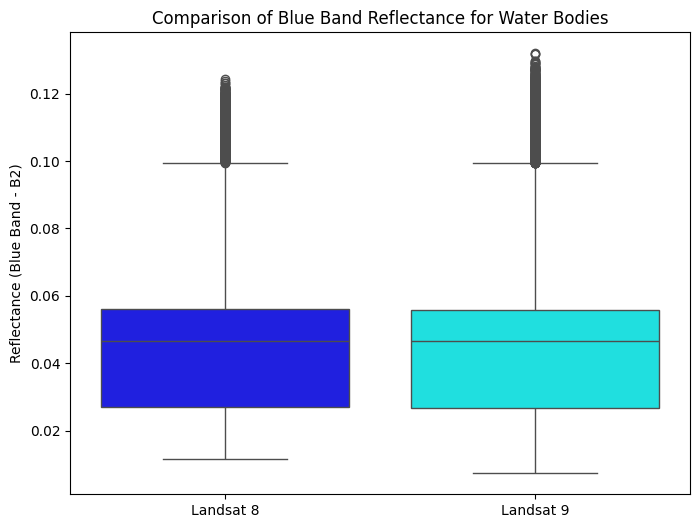

In [ ]:
l8_blue = read_blue_band(l8_path)
l9_blue = read_blue_band(l9_path)

l8_blue_flat = l8_blue.flatten()
l9_blue_flat = l9_blue.flatten()

valid_mask = (l8_blue_flat > 0) & (l9_blue_flat > 0)  
l8_blue_valid = l8_blue_flat[valid_mask]
l9_blue_valid = l9_blue_flat[valid_mask]

# Check if we have valid pixels
if len(l8_blue_valid) == 0 or len(l9_blue_valid) == 0:
    print("No valid data found in the Blue Band (B2). Please check raster files.")
    exit()

# Normality Test (Shapiro-Wilk)
shapiro_l8 = stats.shapiro(l8_blue_valid)
shapiro_l9 = stats.shapiro(l9_blue_valid)

print("Shapiro-Wilk Test for Normality:")
print(f"Landsat 8 Blue Band: W={shapiro_l8.statistic}, p={shapiro_l8.pvalue}")
print(f"Landsat 9 Blue Band: W={shapiro_l9.statistic}, p={shapiro_l9.pvalue}")

# Choose test based on normality
if shapiro_l8.pvalue > 0.05 and shapiro_l9.pvalue > 0.05:
    # Data is normal, use Paired t-Test
    t_stat, p_value = stats.ttest_rel(l8_blue_valid, l9_blue_valid)
    test_used = "Paired t-Test"
else:
    # Data is not normal, use Wilcoxon Signed-Rank Test
    t_stat, p_value = stats.wilcoxon(l8_blue_valid, l9_blue_valid)
    test_used = "Wilcoxon Signed-Rank Test"

print(f"\n{test_used} Results:")
print(f"T-Statistic: {t_stat}, P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Significant difference: Landsat 9 performs better for water detection.")
else:
    print("No significant difference between L8 and L9 for water detection.")

# Boxplot Visualization
plt.figure(figsize=(8, 6))
sns.boxplot(data=[l8_blue_valid, l9_blue_valid], palette=["blue", "cyan"])
plt.xticks([0, 1], ["Landsat 8", "Landsat 9"])
plt.ylabel("Reflectance (Blue Band - B2)")
plt.title("Comparison of Blue Band Reflectance for Water Bodies")
plt.show()